# Guardrailed Auto‑Trading Agent Backtest (Historical Simulator)
1. **AAPL only (OHLCV + optional Yahoo fundamentals)**
2. DeepSeek **risk overlay** • Monthly LLM policy + monthly guardrail reoptimization
3. Data from **1990 onward**, out‑of‑sample (OOS) results from **2023 onward**

## What we are backtesting
Each day, an **LLM risk manager sets AAPL's target exposure** using market-state statistics derived from OHLCV data.

We compare three curves:
1. **Agent‑only**: positions set by the LLM risk overlay + momentum tilt, no hard guardrails.
2. **Agent + Guardrails**: LLM overlay **plus** feature-conditioned hard risk gates.
3. **Buy & Hold AAPL**: the plain benchmark.

## How the LLM is used (long-only risk overlay)
The LLM is **not** asked to predict price direction; it acts as a **risk manager**.

Once per month it reads state-level return statistics and outputs a policy table:
**state → {LONG (full/medium conviction) | FLAT (reduce exposure)}**

Each day's target exposure is looked up from the monthly policy table, scaled by the volatility-targeting module, then tilted ±15% by the 3-month momentum signal. The result is a **daily exposure between ~43% and ~115% of the vol-scaled base**, modulated by market regime and trend.

| LLM output | Base exposure | With positive momentum (+15%) | With negative momentum (−15%) |
|---|---|---|---|
| LONG, size 1.0 | 100% | 115% | 85% |
| LONG, size 0.5 | 80% | 92% | 68% |
| FLAT | 50% | 57% | 43% |

All exposures are then clipped to `MAX_LEVERAGE = 1.0`.

## Guardrails (feature-conditioned hard risk gates)
The guardrail layer sits on top of the agent and can override any proposed position:

| Trigger | Condition to fire |
|---|---|
| **Vol stop** | 20-day vol > threshold **AND** 5-day vol accelerating (> 80% of threshold) |
| **DD hard stop** | Drawdown > limit **AND** 3M momentum negative **AND** price < 50-day MA |
| **Warning zone** | Drawdown > 60% of limit → halve position (no confirmation required) |

Requiring multiple confirming signals prevents false stops during high-vol uptrends and short-lived dips that recover quickly.

## Walk‑forward cadence
| Frequency | What is updated |
|---|---|
| **Monthly** | LLM policy table (state → action/size), rebuilt from the latest 3-year training window |
| **Monthly** | Guardrail thresholds (vol stop, DD limit, max delta, cooldown), reoptimized to maximize in-sample Sharpe |

Equity is carried continuously across all month boundaries: no monthly reset.

## Transaction costs (Interactive Brokers)
- Commission: **0.28 bps** (IBKR Fixed $0.005/share at AAPL ~$185)
- Slippage: **0.37 bps** (half the $0.01 bid-ask spread + buffer for vol-spike widenings)
- **Total: 0.65 bps** one-way per unit of notional traded

> Disclaimer: Educational backtest only. Not investment advice.

In [1]:
# (Optional) Install dependencies if needed
# !pip install -q pandas numpy yfinance matplotlib requests

## 1) Settings: edit only this cell

All hyperparameters live here so you never need to touch the logic cells below.

| Group | Key parameters |
|---|---|
| **API** | `DEEPSEEK_API_KEY`, `DEEPSEEK_MODEL`: credentials for the LLM risk manager |
| **Universe** | `SYMBOL = "AAPL"`, `START = "1990-01-01"`, `OOS_START = "2023-01-01"` |
| **Features** | `RET_WIN`, `VOL_WIN`, `ZSCORE_WIN`: all set to 20 days |
| **Costs** | `COST_BPS = 0.28`, `SLIPPAGE_BPS = 0.37` → `TC_BPS = 0.65` (IBKR Fixed) |
| **Sizing** | `TARGET_VOL = 0.25`, `MAX_LEVERAGE = 1.0`: vol-targeting parameters |
| **Exposure mapping** | `LONG_FULL_EXP = 1.0`, `LONG_HALF_EXP = 0.8`, `FLAT_EXP = 0.5` |
| **Walk-forward** | `TRAIN_YEARS = 3`, `OPT_FREQ_MONTHS = 1` (monthly guardrail reopt, same cadence as LLM policy) |
| **Guardrail grids** | `VOL_STOP_MULT_GRID`, `DD_LIMIT_GRID`, `MAX_DELTA_GRID`, `COOLDOWN_DAYS_GRID` |
| **Re-entry** | `MAX_FLAT_DAYS = 10`, `REENTRY_SIZE = 1.0`: prevents permanent lockout |

In [2]:
# ---------- DeepSeek settings ----------
DEEPSEEK_API_KEY = ""
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
DEEPSEEK_MODEL = "deepseek-chat"

# ---------- Policy mode (B3) ----------
# "llm"  -> ask DeepSeek to assess risk and set exposure (needs API key)
# "rule" -> deterministic baseline from sharpe_like stats (no API key needed)
POLICY_MODE = "llm"
RULE_TAU = 0.5
RULE_MIN_COUNT = 20

# ---------- Data settings ----------
SYMBOL = "AAPL"
START = "1990-01-01"
OOS_START = "2023-01-01"

# ---------- Feature windows ----------
RET_WIN = 20
VOL_WIN = 20
ZSCORE_WIN = 20

# ---------- Backtest costs: Interactive Brokers (IBKR) Fixed pricing ----------
# Commission: IBKR Fixed rate $0.005/share; at AAPL ~$185 → 0.27 bps
# Regulatory: SEC Section 31 + FINRA TAF on sales (round-trip average) → ~0.005 bps
# Slippage:   half the $0.01 AAPL bid-ask spread → 0.27 bps; +0.10 bps buffer for
#             wider spreads during vol spikes (e.g. earnings, macro events)
COST_BPS     = 0.28   # commission + regulatory fees
SLIPPAGE_BPS = 0.37   # half bid-ask + vol-spike buffer
TC_BPS = COST_BPS + SLIPPAGE_BPS   # = 0.65 bps total one-way cost per unit notional

# ---------- Position sizing: volatility targeting (B2) ----------
USE_VOL_TARGET = True
TARGET_VOL = 0.25
MAX_LEVERAGE = 1.0

# ---------- LLM exposure mapping (long-only risk overlay) ----------
LONG_FULL_EXP = 1.0   # LLM says LONG, size 1.0
LONG_HALF_EXP = 0.8   # LLM says LONG, size 0.5
FLAT_EXP      = 0.5   # LLM says FLAT (risk-off, partially invested)

# ---------- Monthly walk-forward ----------
TRAIN_YEARS = 3

# ---------- Guardrail re-optimization cadence (A4) ----------
OPT_FREQ_MONTHS = 1   # 1=monthly (same cadence as the LLM policy)

# ---------- State buckets ----------
Z_EDGE = 1.0

# ---------- Guardrail grids ----------
VOL_STOP_MULT_GRID = [1.5, 2.0, 3.0]
DD_LIMIT_GRID      = [0.12, 0.15, 0.20]
MAX_DELTA_GRID     = [0.5, 1.0]
COOLDOWN_DAYS_GRID = [3, 5, 7]

# ---------- Guardrail re-entry (prevents permanent lockout) ----------
# After a drawdown stop, force re-entry at full size after MAX_FLAT_DAYS trading days.
# Without this, a strategy that goes flat stops accruing equity, the drawdown
# never recovers, and the drawdown check keeps firing indefinitely (deadlock).
MAX_FLAT_DAYS = 10    # ~2 trading weeks before forced re-entry
REENTRY_SIZE  = 1.0   # full re-entry so equity recovers the drawdown faster

# ---------- LLM policy cache ----------
POLICY_CACHE_FILE = "deepseek_policy_cache_aapl.json"
LLM_TIMEOUT_S = 30
LLM_RATE_LIMIT_S = 0.25

## 2) Imports

Loads the five packages used throughout the notebook. No custom dependencies: everything is available via `pip`.

| Package | Purpose |
|---|---|
| `numpy`, `pandas` | Numerical computation and time-series manipulation |
| `matplotlib` | Equity curve plots |
| `yfinance` | AAPL OHLCV download from Yahoo Finance |
| `requests` | HTTP calls to the DeepSeek chat API |
| `json`, `math`, `time`, `re`, `pathlib` | Standard library: JSON cache, math helpers, rate-limiting, path handling |

In [3]:
import json, math, time, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import requests

## 3) Download AAPL daily OHLCV (1990 – present)

Downloads 35+ years of split- and dividend-adjusted AAPL prices from Yahoo Finance.

**Why `auto_adjust=True` is critical:** AAPL has split four times since 1990 (2:1 in 1987, 2:1 in 2000, 7:1 in 2014, 4:1 in 2020). Without adjustment, each split day would contain a fake log-return of −50% to −86%, which would poison the rolling volatility, trend score, z-score, state buckets, and every downstream metric. Pinning `auto_adjust=True` prevents this regardless of the installed yfinance version.

The cell also normalises the column index (yfinance can return single- or multi-level columns depending on version) and prints a sanity-check on the five largest absolute daily moves to confirm no split artefacts survived.

In [4]:
# Download daily OHLCV.
# A1: pin auto_adjust=True so Close is split/dividend-adjusted. AAPL has split
# many times since 1990 (incl. 7:1 in 2014, 4:1 in 2020); without adjustment the
# log-return series would contain huge fake jumps on split days and poison every
# downstream stat. Pinning it also silences the yfinance default-change warning.
df = yf.download(SYMBOL, start=START, interval="1d", progress=False, auto_adjust=True)

# yfinance may return single- or multi-level columns depending on version.
if isinstance(df.columns, pd.MultiIndex):
    df = df.xs(SYMBOL, axis=1, level=-1) if SYMBOL in df.columns.get_level_values(-1) else df.droplevel(-1, axis=1)
df.index = pd.to_datetime(df.index)

print("Rows:", len(df))
print("Start:", df.index.min().date())
print("End  :", df.index.max().date())

df.head()

Rows: 9183
Start: 1990-01-02
End  : 2026-06-18


Price,Close,High,Low,Open,Volume
Date,,,,,
1990-01-02,0.260465,0.262213,0.244733,0.246481,183198400
1990-01-03,0.262213,0.265710,0.262213,0.265710,207995200
1990-01-04,0.263088,0.270954,0.260465,0.267458,221513600
1990-01-05,0.263962,0.267458,0.258717,0.263962,123312000
1990-01-08,0.265710,0.265710,0.258717,0.262213,101572800


## 4) Optional: current fundamentals snapshot

Fetches a one-time snapshot of AAPL fundamentals (P/E, P/B, beta, profit/gross/operating margins, ROE) from Yahoo Finance's `Ticker.info` endpoint.

**Important:** this is a *current* snapshot, not a historical time series. It is printed for context only and is **never used in the backtest**. Feeding it into the strategy would introduce lookahead bias. Treat it as background information when interpreting OOS results.

In [5]:
# This is optional context. It's a snapshot (current), not a historical time series.
# We do NOT use it directly in the backtest math (to avoid lookahead).
try:
    info = yf.Ticker(SYMBOL).info or {}
    fundamentals = {k: info.get(k) for k in [
        "marketCap","trailingPE","forwardPE","priceToBook","beta",
        "profitMargins","grossMargins","operatingMargins","returnOnEquity"
    ]}
except Exception:
    fundamentals = {}

fundamentals

{'marketCap': 4376979046400,
 'trailingPE': 36.122425,
 'forwardPE': 31.040802,
 'priceToBook': 41.04821,
 'beta': 1.086,
 'profitMargins': 0.27152002,
 'grossMargins': 0.47862,
 'operatingMargins': 0.32275,
 'returnOnEquity': 1.4147099}

## 5) Feature engineering (OHLCV → signals)

Seven features are computed from the daily OHLCV series:

| Feature | Formula | Used for |
|---|---|---|
| `ret` | log(Close) − log(Close_prev) | returns everywhere |
| `vol` | 20-day rolling std × √252 | vol-targeting, state bucket, guardrail vol stop |
| `trend` | 20-day mean / 20-day std | state bucket (TREND_UP / TREND_DOWN) |
| `z` | (Close − 20-day MA) / 20-day std | state bucket (Z_LOW / Z_MID / Z_HIGH) |
| `mom63` | 63-day cumulative log return | momentum tilt (±15%) + DD stop condition |
| `vol5` | 5-day rolling std × √252 | vol acceleration condition in vol stop |
| `ma50` | 50-day simple moving average | trend confirmation in DD stop |

In [6]:
feat = df.copy()

# Daily log returns
feat["ret"] = np.log(feat["Close"]).diff()

# Rolling annualized volatility (20-day)
feat["vol"] = feat["ret"].rolling(VOL_WIN).std() * np.sqrt(252)

# Trend score: rolling mean / rolling std (simple, interpretable)
rmean = feat["ret"].rolling(RET_WIN).mean()
rstd  = feat["ret"].rolling(RET_WIN).std()
feat["trend"] = (rmean / (rstd + 1e-12)).clip(-5, 5)

# Price z-score (mean reversion indicator)
ma = feat["Close"].rolling(ZSCORE_WIN).mean()
sd = feat["Close"].rolling(ZSCORE_WIN).std()
feat["z"] = ((feat["Close"] - ma) / (sd + 1e-12)).clip(-6, 6)

# 3-month (63-day) cumulative log return: momentum tilt signal and guardrail condition.
# Negative value means AAPL has been in a downtrend over the past quarter.
feat["mom63"] = feat["ret"].rolling(63).sum()

# 5-day (1-week) short-term annualised vol: vol acceleration proxy for the guardrail vol stop.
# When vol5 exceeds 80% of the optimised vol-stop threshold, short-term vol is spiking
# rapidly: a stronger sell signal than high-but-stable long-run vol.
feat["vol5"] = feat["ret"].rolling(5).std() * np.sqrt(252)

# 50-day moving average: trend confirmation for the drawdown stop.
# Requiring price < MA50 before cutting exposure prevents false stops during
# normal intra-trend pullbacks that stay above the intermediate trend.
feat["ma50"] = feat["Close"].rolling(50).mean()

# Keep only rows with full features
feat = feat.dropna()

# A1 sanity check: inspect the largest single-day moves. With split-adjusted data
# the biggest legitimate AAPL move is ~-52% (2000-09-29, earnings warning) -> |log ret| ~0.73.
# Unadjusted split days would show even larger jumps (4:1 -> ~1.39, 7:1 -> ~1.95).
_top = feat["ret"].abs().sort_values(ascending=False).head(5)
print("Largest |daily log return| moves (check these are real events, not split artifacts):")
for d, v in _top.items():
    print(f"  {d.date()}  {feat.loc[d, 'ret']:+.2%}")
if feat["ret"].abs().max() > 1.0:
    print("WARNING: a >100% single-day move suggests UNADJUSTED data (split artifact). Verify auto_adjust=True.")

feat[["Close","ret","vol","vol5","ma50","mom63","trend","z"]].tail()

Largest |daily log return| moves (check these are real events, not split artifacts):
  2000-09-29  -73.12%
  1997-08-06  +28.69%
  1993-07-16  -26.24%
  1998-01-02  +21.36%
  1996-07-18  +21.27%


Price,Close,ret,vol,vol5,ma50,mom63,trend,z
Date,,,,,,,,
2026-06-12,291.130005,-0.015339,0.239139,0.316723,285.362105,0.152750,-0.079751,-1.662410
2026-06-15,296.420013,0.018007,0.247302,0.362179,286.176816,0.160020,-0.040991,-0.930724
2026-06-16,299.239990,0.009468,0.248181,0.206720,286.989182,0.163927,0.014998,-0.582346
2026-06-17,295.950012,-0.011055,0.250940,0.240414,287.842849,0.169891,-0.032113,-0.970906
2026-06-18,298.010010,0.006937,0.248930,0.225434,288.629816,0.180756,-0.045046,-0.674797


## 6) Build the discrete market state

Buckets three continuous signals into discrete labels and concatenates them into a single state string that the LLM policy will act on.

| Signal | Buckets | Logic |
|---|---|---|
| `trend` (20-day mean/std) | `TREND_UP` / `TREND_DOWN` | Sign of the trend score |
| `vol` (20-day realised) | `VOL_HIGH` / `VOL_LOW` | Above or below the trailing 252-day median vol |
| `z` (20-day price z-score) | `Z_LOW` / `Z_MID` / `Z_HIGH` | Below −1, between ±1, above +1 |

This produces **12 possible states** (2 × 2 × 3), for example `TREND_UP|VOL_HIGH|Z_MID`. The vol bucket uses a *rolling* median so the HIGH/LOW split adapts to long-run regime changes rather than using a fixed threshold.

In [7]:
# We bucket a few signals into labels and combine them into one "state" string.
# This is what the LLM policy will act on.

trend_bucket = np.where(feat["trend"] >= 0, "TREND_UP", "TREND_DOWN")

# Volatility bucket: compare to rolling median (adaptive)
vol_med = feat["vol"].rolling(252, min_periods=60).median()
vol_bucket = np.where(feat["vol"] > vol_med, "VOL_HIGH", "VOL_LOW")

# Z-score bucket
z = feat["z"]
z_bucket = np.where(z <= -Z_EDGE, "Z_LOW", np.where(z >= Z_EDGE, "Z_HIGH", "Z_MID"))

feat["state"] = [f"{trend_bucket[i]}|{vol_bucket[i]}|{z_bucket[i]}" for i in range(len(feat))]

feat["state"].value_counts().head(10)

state
TREND_UP|VOL_LOW|Z_HIGH      1814
TREND_UP|VOL_HIGH|Z_HIGH     1191
TREND_UP|VOL_LOW|Z_MID       1188
TREND_DOWN|VOL_HIGH|Z_MID    1087
TREND_UP|VOL_HIGH|Z_MID      1038
TREND_DOWN|VOL_HIGH|Z_LOW     993
TREND_DOWN|VOL_LOW|Z_LOW      792
TREND_DOWN|VOL_LOW|Z_MID      727
TREND_UP|VOL_LOW|Z_LOW         83
TREND_UP|VOL_HIGH|Z_LOW        80
Name: count, dtype: int64

## 7) DeepSeek API helper and policy cache

Four utility functions that handle all communication with the DeepSeek API:

- **`load_cache` / `save_cache`**: persist completed LLM responses to a local JSON file (`deepseek_policy_cache_aapl.json`). On re-runs, any month already in the cache is skipped entirely: no API call, no wait, no cost. Cache keys include the model name and a `::longonly-v1` version tag so stale entries from earlier short-biased prompts are never served.

- **`deepseek_chat`**: sends a chat completion request to the DeepSeek API with `temperature=0` (deterministic output) and `max_tokens=2000` (enough headroom for a 12-state JSON policy table). Returns the raw response string.

- **`parse_json`**: extracts the first valid JSON object from the response. Tries a direct parse first; if that fails, scans for the outermost `{…}` block. This handles cases where the model wraps its answer in markdown fences or adds a trailing comment.

In [8]:
def load_cache(path):
    p = Path(path)
    if p.exists():
        return json.loads(p.read_text(encoding="utf-8"))
    return {}

def save_cache(path, cache):
    Path(path).write_text(json.dumps(cache, indent=2, sort_keys=True), encoding="utf-8")

def deepseek_chat(messages, max_tokens=2000):
    url = DEEPSEEK_BASE_URL.rstrip("/") + "/chat/completions"
    headers = {"Authorization": f"Bearer {DEEPSEEK_API_KEY}", "Content-Type": "application/json"}
    payload = {
        "model": DEEPSEEK_MODEL,
        "messages": messages,
        "temperature": 0.0,
        "max_tokens": max_tokens,
        "stream": False,
    }
    r = requests.post(url, headers=headers, json=payload, timeout=LLM_TIMEOUT_S)
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"]

def parse_json(text):
    t = text.strip()
    # Try direct parse first
    try:
        return json.loads(t)
    except Exception:
        pass
    # Extract the outermost {...} block
    start = t.find("{")
    end = t.rfind("}")
    if start != -1 and end != -1 and end > start:
        try:
            return json.loads(t[start:end+1])
        except Exception:
            pass
    raise ValueError(f"DeepSeek output did not contain valid JSON.\nRaw output (first 500 chars):\n{t[:500]}")

## 8) Build the LLM risk policy: state → {action, size}

This section handles the LLM policy update. Both the LLM policy and the guardrail parameters are reoptimised every month; the guardrail optimisation is covered in Section 11.

| What | How often | What is produced |
|---|---|---|
| **LLM risk policy** (this section) | Every month | A table mapping each of the 12 states to `{LONG/FLAT, size 0.5/1.0}` |
| **Guardrail parameters** (Section 11) | Every month | Best `{vol_stop, dd_limit, max_delta, cooldown_days}` from a grid search |

Four functions:

- **`state_stats`**: aggregates the training window into per-state statistics: observation count, mean daily return, standard deviation, and a Sharpe-like score (annualised mean/std). This is the input the LLM receives.

- **`rule_policy`**: deterministic baseline (no API call needed): LONG 1.0 when Sharpe-like > threshold, FLAT when negative, LONG 0.5 otherwise. Used in `POLICY_MODE="rule"` and as a fallback when the LLM parse fails twice.

- **`llm_policy`**: constructs a system prompt that frames DeepSeek as a **risk manager** (not a price predictor), and a user message containing the per-state statistics as JSON. The model returns a policy table in strict JSON. A retry loop runs once on parse failure before falling back to `rule_policy`.

- **`build_policy_for_month`**: checks the cache first, then calls the appropriate policy function, validates every action/size against `ALLOWED_ACTIONS`/`ALLOWED_SIZES`, fills any missing state with `LONG 0.5` (stay invested by default), writes the result to cache, and returns the validated table.

In [9]:
ALLOWED_ACTIONS = ["LONG", "FLAT"]   # no shorts: LLM is a risk overlay, not a direction picker
ALLOWED_SIZES = [0.5, 1.0]           # size modulates conviction: 1.0 = high, 0.5 = medium

def state_stats(train_df):
    tmp = train_df.copy()
    tmp["state_lag"] = tmp["state"].shift(1)
    tmp["ret_fwd"] = tmp["ret"]
    tmp = tmp.dropna(subset=["state_lag","ret_fwd"])
    g = tmp.groupby("state_lag")["ret_fwd"]
    stats = pd.DataFrame({
        "count": g.size(),
        "mean": g.mean(),
        "std": g.std(ddof=0),
    })
    stats["sharpe_like"] = (stats["mean"] / (stats["std"] + 1e-12)) * math.sqrt(252)
    return stats.sort_values("count", ascending=False)

def rule_policy(stats):
    # B3 deterministic baseline: LONG 1.0 when Sharpe-like > RULE_TAU, LONG 0.5 when
    # neutral (between ±RULE_TAU), FLAT when Sharpe-like < -RULE_TAU or count < RULE_MIN_COUNT.
    policy = {}
    for state, row in stats.iterrows():
        if int(row["count"]) < RULE_MIN_COUNT or row["sharpe_like"] < -RULE_TAU:
            policy[state] = {"action": "FLAT", "size": 0.5}
        elif row["sharpe_like"] > RULE_TAU:
            policy[state] = {"action": "LONG", "size": 1.0}
        else:
            policy[state] = {"action": "LONG", "size": 0.5}
    return policy

def llm_policy(month_start, stats):
    rows = []
    for state, row in stats.iterrows():
        rows.append({
            "state": state,
            "count": int(row["count"]),
            "mean_daily_ret": round(float(row["mean"]), 6),
            "std_daily_ret": round(float(row["std"]) if not np.isnan(row["std"]) else 0.0, 6),
            "sharpe_like": round(float(row["sharpe_like"]), 3),
        })

    system = (
        "You are a risk manager for a long-only AAPL equity strategy. "
        "Your job is NOT to predict tomorrow's price direction. "
        "Your job is to assess whether each market state carries elevated downside risk "
        "that warrants reducing exposure. "
        "For each market state, output LONG (stay invested) or FLAT (reduce exposure). "
        "Use size 1.0 for states with clearly positive or neutral risk/return, "
        "size 0.5 for states with mildly positive but uncertain evidence. "
        "FLAT means the state shows clearly negative expected return or high downside risk, "
        "use it sparingly, only when the evidence is unambiguous. "
        "Default bias: LONG. Most states should be LONG. "
        "NEVER output SHORT. "
        "Return STRICT JSON only, no commentary:\n"
        '{"policy": {"<state>": {"action": "LONG|FLAT", "size": 0.5|1.0}, ...}}'
    )

    user = {
        "month_start": month_start.date().isoformat(),
        "symbol": SYMBOL,
        "task": "Set LONG or FLAT for each state. Default to LONG. Only FLAT when downside risk is clear.",
        "allowed_actions": ALLOWED_ACTIONS,
        "allowed_sizes": ALLOWED_SIZES,
        "state_statistics": rows,
    }

    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": json.dumps(user)},
    ]

    # Retry once on parse failure (truncation or malformed output)
    for attempt in range(2):
        content = deepseek_chat(messages, max_tokens=2000)
        try:
            obj = parse_json(content)
            return obj.get("policy", {})
        except ValueError as e:
            if attempt == 0:
                print(f"  [llm_policy] parse failed on attempt 1, retrying. Error: {e}")
                time.sleep(1.0)
            else:
                print(f"  [llm_policy] parse failed on both attempts for {month_start.date()}. Falling back to rule policy.")
                return rule_policy(stats)

def build_policy_for_month(month_start, train_df, cache):
    # Cache key includes "longonly-v1" so old SHORT-based entries are never served.
    cache_key = f"{month_start.date().isoformat()}::{SYMBOL}::{DEEPSEEK_MODEL}::{POLICY_MODE}::longonly-v1"
    if cache_key in cache:
        return cache[cache_key]

    stats = state_stats(train_df)

    if POLICY_MODE == "rule":
        raw_policy = rule_policy(stats)
    elif POLICY_MODE == "llm":
        raw_policy = llm_policy(month_start, stats)
    else:
        raise ValueError(f"Unknown POLICY_MODE: {POLICY_MODE!r} (use 'llm' or 'rule').")

    policy = {}
    for s in stats.index.tolist():
        rec = raw_policy.get(s, {"action": "LONG", "size": 0.5})  # default: participate
        action = str(rec.get("action", "LONG")).upper()
        size = float(rec.get("size", 0.5))
        if action not in ALLOWED_ACTIONS:
            action = "LONG"
        if size not in ALLOWED_SIZES:
            size = 0.5
        policy[s] = {"action": action, "size": size}

    cache[cache_key] = policy
    save_cache(POLICY_CACHE_FILE, cache)
    if POLICY_MODE == "llm":
        time.sleep(LLM_RATE_LIMIT_S)
    return policy

## 9) Backtest helpers (positions, costs, equity)

Three building blocks:

- **`action_to_base_exposure`**: maps the LLM output (LONG/FLAT × size) to a base position in [0.5, 1.0].
- **`vol_scale`**: scales the base toward `TARGET_VOL` using the previous day's realized vol (no lookahead). Position is capped at `MAX_LEVERAGE`.
- **`mom_tilt`**: applies a ±15% tilt based on the lagged 63-day cumulative return. Positive momentum → ×1.15; negative → ×0.85. Applied after vol-scaling so the result is always clipped to `MAX_LEVERAGE`.
- **`build_agent_positions`**: chains the three functions above into a daily position series, using full-history lagged state, vol, and momentum to avoid the artificial monthly flatten (fix A3).
- **`equity_from_positions`**: converts a position series to a cumulative equity curve, charging `TC_BPS = 0.65 bps` (IBKR) on every unit of notional change. No extra lag (fix A2).

In [10]:
def action_to_base_exposure(action, size):
    # Maps LLM output to a base exposure in [0.5, 1.0]. No shorts.
    # The LLM acts as a risk overlay: LONG = stay invested (full or high conviction),
    # FLAT = reduce exposure (step back but don't fully exit, per FLAT_EXP setting).
    if action == "LONG":
        return LONG_FULL_EXP if size >= 1.0 else LONG_HALF_EXP
    return FLAT_EXP  # FLAT

def vol_scale(base, v):
    # B2: scale a position toward TARGET_VOL using (lagged) realized vol, capped.
    if not USE_VOL_TARGET or base == 0.0:
        return base
    if pd.isna(v) or float(v) <= 0:
        return base
    return base * min(TARGET_VOL / float(v), MAX_LEVERAGE)

def mom_tilt(base, m):
    # Momentum overlay: tilt exposure ±15% based on 3-month cumulative return.
    # Positive momentum → scale up by 15% (stay with the trend).
    # Negative momentum → scale down by 15% (reduce into weakness).
    # Tilt is applied AFTER vol-scaling so it never pushes above MAX_LEVERAGE.
    if pd.isna(m):
        return base
    tilt = 1.15 if float(m) >= 0 else 0.85
    return base * tilt

def build_agent_positions(df_seg, policy, state_lag=None, vol_lag=None, mom_lag=None):
    # pos[t] = target exposure to hold during day t, decided from state at close of t-1.
    # Continuous state_lag/vol_lag can be passed in to avoid forced flat at month starts (A3).
    if state_lag is None:
        state_lag = df_seg["state"].shift(1)
    if vol_lag is None:
        vol_lag = df_seg["vol"].shift(1)
    if mom_lag is None:
        mom_lag = df_seg["mom63"].shift(1) if "mom63" in df_seg.columns else pd.Series(np.nan, index=df_seg.index)

    pos = pd.Series(0.0, index=df_seg.index)
    for t in df_seg.index:
        s = state_lag.loc[t]
        if pd.isna(s):
            continue
        rec = policy.get(s, {"action": "LONG", "size": 0.5})  # default: participate
        base = action_to_base_exposure(rec["action"], rec["size"])
        scaled = vol_scale(base, vol_lag.loc[t])
        pos.loc[t] = min(mom_tilt(scaled, mom_lag.loc[t]), MAX_LEVERAGE)
    return pos

def equity_from_positions(df_seg, pos_target):
    # A2: pos_target[t] is the position held during day t: no extra shift needed.
    executed = pos_target.fillna(0.0)
    cost = (TC_BPS / 10000.0) * pos_target.diff().abs().fillna(0.0)
    net = executed * df_seg["ret"].fillna(0.0) - cost
    eq = np.exp(net.cumsum())
    return pd.Series(eq, index=df_seg.index)

## 10) Guardrails (feature-conditioned hard risk gates)

The guardrail layer overrides the agent's proposed position on days when multiple risk signals align. All thresholds (`vol_stop`, `dd_limit`, `max_delta`, `cooldown_days`) are optimized monthly on the training window.

### Three-tier risk response

| Priority | Condition | Action |
|---|---|---|
| 1: Cooldown | Days remaining after a stop event | Hold flat; count down |
| 2: Forced re-entry | Flat for ≥ `MAX_FLAT_DAYS` (10) trading days | Re-enter at `REENTRY_SIZE` (1.0×); reset drawdown peak |
| 3: Vol stop | 20-day vol > `vol_stop` **AND** 5-day vol > `vol_stop × 0.8` | Exit fully; start cooldown |
| 4: DD hard stop | DD < −`dd_limit` **AND** `mom63 < 0` **AND** price < MA50 | Exit fully; start cooldown |
| 5: Warning zone | −`dd_limit` < DD < −60% of `dd_limit` | Halve the agent's proposed position |
| 6: Normal | None of the above | Pass agent's position through unchanged |

### Why require multiple conditions?
A single vol or drawdown threshold fires too often in trending markets. AAPL's high-vol periods in 2023-2025 were frequently followed by sharp recoveries. Requiring vol *acceleration* (vol5 > threshold) and a *broken trend* (negative 3M momentum + price below MA50) means the guardrail only acts when evidence of genuine deterioration is present on multiple independent axes.

### `max_delta`: position change limiter
Caps the size of any single-day position adjustment to smooth out whipsaw.  Optimized values are typically 0.5 or 1.0 (full re-entry in one step).

In [11]:
def apply_guardrails_day_by_day(df_seg, proposed_pos, vol_stop, dd_limit, max_delta, cooldown_days,
                                vol_lag=None, vol5_lag=None, mom63_lag=None,
                                price_lag=None, ma50_lag=None,
                                equity0=1.0, peak0=None, prev_target0=0.0, cooldown0=0):
    pos = pd.Series(0.0, index=df_seg.index)
    equity = float(equity0)
    peak = float(peak0) if peak0 is not None else equity
    cooldown = int(cooldown0)
    prev_target = float(prev_target0)
    flat_days = 0

    warn_threshold = dd_limit * 0.60  # warning zone: 60% of hard limit

    if vol_lag   is None: vol_lag   = df_seg["vol"].shift(1)
    if vol5_lag  is None: vol5_lag  = df_seg["vol5"].shift(1)  if "vol5"  in df_seg.columns else pd.Series(np.nan, index=df_seg.index)
    if mom63_lag is None: mom63_lag = df_seg["mom63"].shift(1) if "mom63" in df_seg.columns else pd.Series(np.nan, index=df_seg.index)
    if price_lag is None: price_lag = df_seg["Close"].shift(1) if "Close" in df_seg.columns else pd.Series(np.nan, index=df_seg.index)
    if ma50_lag  is None: ma50_lag  = df_seg["ma50"].shift(1)  if "ma50"  in df_seg.columns else pd.Series(np.nan, index=df_seg.index)

    # Vol acceleration threshold: vol_stop * 0.8 (see vol_accelerating check below)

    for t in df_seg.index:
        dd     = equity / peak - 1.0
        target = float(proposed_pos.loc[t])

        if cooldown > 0:
            target = 0.0
            cooldown -= 1
        else:
            if flat_days >= MAX_FLAT_DAYS:
                # Force re-entry after MAX_FLAT_DAYS flat; reset peak so DD check restarts.
                target = target * REENTRY_SIZE
                peak = equity
            else:
                v     = vol_lag.loc[t]
                v5    = vol5_lag.loc[t]
                m63   = mom63_lag.loc[t]
                px    = price_lag.loc[t]
                ma    = ma50_lag.loc[t]
                wt    = warn_threshold

                # Vol stop: fires when vol is elevated AND short-term vol is accelerating.
                # Requiring acceleration avoids false stops in high-but-stable vol (e.g.
                # trending rallies with elevated daily swings).
                vol_accelerating = pd.notna(v5) and (float(v5) > vol_stop * 0.8)
                if pd.notna(v) and float(v) > vol_stop and vol_accelerating:
                    target = 0.0
                    if cooldown_days > 0:
                        cooldown = cooldown_days

                # DD stop: fires only when drawdown is confirmed by two trend signals.
                # Requiring negative 3M momentum AND price below the 50-day MA prevents
                # false stops during normal intra-trend dips that recover quickly.
                elif dd < -dd_limit:
                    trend_broken = (pd.notna(m63) and float(m63) < 0 and
                                    pd.notna(px) and pd.notna(ma) and float(px) < float(ma))
                    if trend_broken:
                        target = 0.0
                        if cooldown_days > 0:
                            cooldown = cooldown_days

                # Warning zone: reduce to half size when approaching the hard limit
                # (regardless of trend confirmation: caution is warranted near the edge).
                elif dd < -wt:
                    target = target * 0.5

        delta = target - prev_target
        if abs(delta) > max_delta:
            target = prev_target + math.copysign(max_delta, delta)

        pos.loc[t] = target
        flat_days = flat_days + 1 if target == 0.0 else 0

        r    = float(df_seg.loc[t, "ret"])
        cost = (TC_BPS / 10000.0) * abs(target - prev_target)
        equity *= math.exp(target * r - cost)
        peak = max(peak, equity)
        prev_target = target

    return pos


def apply_guardrails_oos(df_seg, proposed_pos, params_by_day, vol_lag,
                         vol5_lag=None, mom63_lag=None, price_lag=None, ma50_lag=None):
    pos = pd.Series(0.0, index=df_seg.index)
    equity = 1.0; peak = 1.0; cooldown = 0; prev_target = 0.0; flat_days = 0

    if vol5_lag  is None: vol5_lag  = df_seg["vol5"].shift(1)  if "vol5"  in df_seg.columns else pd.Series(np.nan, index=df_seg.index)
    if mom63_lag is None: mom63_lag = df_seg["mom63"].shift(1) if "mom63" in df_seg.columns else pd.Series(np.nan, index=df_seg.index)
    if price_lag is None: price_lag = df_seg["Close"].shift(1) if "Close" in df_seg.columns else pd.Series(np.nan, index=df_seg.index)
    if ma50_lag  is None: ma50_lag  = df_seg["ma50"].shift(1)  if "ma50"  in df_seg.columns else pd.Series(np.nan, index=df_seg.index)


    for t in df_seg.index:
        p      = params_by_day[t]
        dd     = equity / peak - 1.0
        target = float(proposed_pos.loc[t])
        wt     = p["dd_limit"] * 0.60

        if cooldown > 0:
            target = 0.0
            cooldown -= 1
        else:
            if flat_days >= MAX_FLAT_DAYS:
                target = target * REENTRY_SIZE
                peak = equity
            else:
                v   = vol_lag.loc[t]
                v5  = vol5_lag.loc[t]
                m63 = mom63_lag.loc[t]
                px  = price_lag.loc[t]
                ma  = ma50_lag.loc[t]

                vol_accelerating = pd.notna(v5) and (float(v5) > p["vol_stop"] * 0.8)
                if pd.notna(v) and float(v) > p["vol_stop"] and vol_accelerating:
                    target = 0.0
                    if p["cooldown_days"] > 0:
                        cooldown = p["cooldown_days"]
                elif dd < -p["dd_limit"]:
                    trend_broken = (pd.notna(m63) and float(m63) < 0 and
                                    pd.notna(px) and pd.notna(ma) and float(px) < float(ma))
                    if trend_broken:
                        target = 0.0
                        if p["cooldown_days"] > 0:
                            cooldown = p["cooldown_days"]
                elif dd < -wt:
                    target = target * 0.5

        delta = target - prev_target
        if abs(delta) > p["max_delta"]:
            target = prev_target + math.copysign(p["max_delta"], delta)

        pos.loc[t] = target
        flat_days = flat_days + 1 if target == 0.0 else 0

        r    = float(df_seg.loc[t, "ret"])
        cost = (TC_BPS / 10000.0) * abs(target - prev_target)
        equity *= math.exp(target * r - cost)
        peak = max(peak, equity)
        prev_target = target

    return pos

## 11) Walk‑forward loop (2023+ OOS)

### Monthly update schedule

Every OOS month the loop:
1. Defines the training window (last `TRAIN_YEARS = 3` years up to month start)
2. Computes state-level return statistics on the training window
3. Calls the LLM (or rule baseline) to build a fresh policy table: **state → {action, size}**
4. Runs a grid search over `VOL_STOP_MULT_GRID × DD_LIMIT_GRID × MAX_DELTA_GRID × COOLDOWN_DAYS_GRID` to reoptimise guardrail thresholds, maximizing in-sample Sharpe
5. Applies the policy and guardrail parameters to the test month to get daily positions

Both the LLM policy and guardrail parameters are refreshed every month from the same training window. This means guardrail thresholds adapt as quickly as the LLM's risk assessment, at the cost of more grid-search computation per run.

### Continuity across boundaries
All feature lags (`state`, `vol`, `mom63`, `vol5`, `price`, `ma50`) are computed over the **full** history before slicing into monthly segments. This ensures the first trading day of each month uses the genuinely-available prior day's values rather than NaN (fix A3). Equity is similarly carried forward: there is no monthly reset of the position or equity curve.

In [12]:
def month_starts(index, start):
    months = pd.date_range(start=start, end=index.max(), freq="MS")
    return [m for m in months if (index >= m).any()]

def sharpe_from_equity(eq):
    r = eq.pct_change().fillna(0.0)
    ann_ret = r.mean() * 252
    ann_vol = r.std(ddof=0) * math.sqrt(252)
    return float(ann_ret / (ann_vol + 1e-12))

def optimize_guardrails(train_df, policy):
    # Build agent proposals on train window (no guardrails)
    proposed = build_agent_positions(train_df, policy)

    vol_med = float(train_df["vol"].median())
    best_params = None
    best_score = -1e9

    for mult in VOL_STOP_MULT_GRID:
        for dd_lim in DD_LIMIT_GRID:
            for max_delta in MAX_DELTA_GRID:
                for cd in COOLDOWN_DAYS_GRID:
                    params = {
                        "vol_stop":      mult * vol_med,
                        "dd_limit":      dd_lim,
                        "max_delta":     max_delta,
                        "cooldown_days": cd,
                    }
                    guarded_pos = apply_guardrails_day_by_day(train_df, proposed, **params)
                    eq = equity_from_positions(train_df, guarded_pos)
                    score = sharpe_from_equity(eq)

                    if score > best_score:
                        best_score = score
                        best_params = params

    return best_params

def run_walk_forward_oos(feat_all):
    oos_start = pd.to_datetime(OOS_START)
    months = month_starts(feat_all.index, oos_start)

    cache = load_cache(POLICY_CACHE_FILE)

    # Continuous lagged series over the full history (A3: no forced flatten at month starts).
    state_lag_full = feat_all["state"].shift(1)
    vol_lag_full   = feat_all["vol"].shift(1)
    mom_lag_full   = feat_all["mom63"].shift(1)
    vol5_lag_full  = feat_all["vol5"].shift(1)
    price_lag_full = feat_all["Close"].shift(1)
    ma50_lag_full  = feat_all["ma50"].shift(1)

    # 1) Per-month policy + guardrail params (guardrails re-optimized on cadence A4)
    month_blocks = []
    best_guard = None
    for m in months:
        next_m = (m + pd.offsets.MonthBegin(1)).normalize()
        test = feat_all.loc[(feat_all.index >= m) & (feat_all.index < next_m)]
        if len(test) < 5:
            continue
        train_start = (m - pd.DateOffset(years=TRAIN_YEARS)).normalize()
        train = feat_all.loc[(feat_all.index >= train_start) & (feat_all.index < m)]
        if len(train) < 252:
            continue

        policy = build_policy_for_month(m, train, cache)

        # A4: re-optimize guardrails every month (OPT_FREQ_MONTHS=1 means this fires on every iteration).
        if best_guard is None or ((m.month - 1) % OPT_FREQ_MONTHS == 0):
            best_guard = optimize_guardrails(train, policy)
            print("Re-opt guardrails @", m.date(), "->", best_guard)

        month_blocks.append((test.index, policy, best_guard))

    if not month_blocks:
        raise RuntimeError("No OOS months had enough training data.")

    # 2) Assemble one continuous OOS index
    oos_index = month_blocks[0][0]
    for idx, _, _ in month_blocks[1:]:
        oos_index = oos_index.append(idx)
    feat_oos      = feat_all.loc[oos_index]
    vol_lag_oos   = vol_lag_full.loc[oos_index]
    vol5_lag_oos  = vol5_lag_full.loc[oos_index]
    mom63_lag_oos = mom_lag_full.loc[oos_index]
    price_lag_oos = price_lag_full.loc[oos_index]
    ma50_lag_oos  = ma50_lag_full.loc[oos_index]

    # 3) Continuous agent target positions + per-day guardrail params
    agent_parts = []
    params_by_day = {}
    for idx, policy, guard in month_blocks:
        seg = feat_all.loc[idx]
        agent_parts.append(build_agent_positions(
            seg, policy,
            state_lag=state_lag_full.loc[idx],
            vol_lag=vol_lag_full.loc[idx],
            mom_lag=mom_lag_full.loc[idx],
        ))
        for t in idx:
            params_by_day[t] = guard
    agent_pos = pd.concat(agent_parts)

    # 4) Agent-only equity (continuous, single-lagged)
    eq_agent_oos = equity_from_positions(feat_oos, agent_pos)
    eq_agent_oos = eq_agent_oos / eq_agent_oos.iloc[0]

    # 5) Guardrailed equity: passes all feature lags for conditioned triggers
    guard_pos = apply_guardrails_oos(
        feat_oos, agent_pos, params_by_day,
        vol_lag=vol_lag_oos,
        vol5_lag=vol5_lag_oos,
        mom63_lag=mom63_lag_oos,
        price_lag=price_lag_oos,
        ma50_lag=ma50_lag_oos,
    )
    eq_guard_oos = equity_from_positions(feat_oos, guard_pos)
    eq_guard_oos = eq_guard_oos / eq_guard_oos.iloc[0]

    # 6) B1: buy-and-hold AAPL over the identical OOS window
    eq_bh = np.exp(feat_oos["ret"].fillna(0.0).cumsum())
    eq_bh = eq_bh / eq_bh.iloc[0]

    return eq_agent_oos, eq_guard_oos, eq_bh

## 12) Run the walk-forward backtest

Single entry point that validates the configuration and launches the full OOS simulation.

- In `POLICY_MODE="llm"`: makes one DeepSeek API call per OOS month (~40 calls for 2023–2026). Completed months are served from cache, so partial runs resume where they left off. Expect **15–20 minutes** for a cold run; near-instant if the cache is already populated.
- In `POLICY_MODE="rule"`: runs entirely offline using the deterministic baseline, useful for testing code changes without an API key.

The cell prints a progress line for each monthly guardrail reoptimisation so you can follow along, and finishes with the final equity values for all three curves.

In [13]:
# The DeepSeek key is only needed in LLM mode; POLICY_MODE="rule" runs offline.
if POLICY_MODE == "llm" and DEEPSEEK_API_KEY.strip() == "PASTE_YOUR_DEEPSEEK_KEY_HERE":
    raise ValueError("Paste your DeepSeek API key into DEEPSEEK_API_KEY (or set POLICY_MODE='rule'), then rerun.")

eq_agent_oos, eq_guard_oos, eq_bh_oos = run_walk_forward_oos(feat)

print("POLICY_MODE:", POLICY_MODE)
print("OOS start:", eq_agent_oos.index.min().date())
print("OOS end  :", eq_agent_oos.index.max().date())
print("Final equity -> agent: %.3f | guardrails: %.3f | buy&hold: %.3f"
      % (eq_agent_oos.iloc[-1], eq_guard_oos.iloc[-1], eq_bh_oos.iloc[-1]))

Re-opt guardrails @ 2023-01-01 -> {'vol_stop': 0.45074678499599286, 'dd_limit': 0.15, 'max_delta': 1.0, 'cooldown_days': 3}
Re-opt guardrails @ 2023-02-01 -> {'vol_stop': 0.45918054621762516, 'dd_limit': 0.15, 'max_delta': 1.0, 'cooldown_days': 5}
Re-opt guardrails @ 2023-03-01 -> {'vol_stop': 0.6080716326941408, 'dd_limit': 0.2, 'max_delta': 1.0, 'cooldown_days': 7}
Re-opt guardrails @ 2023-04-01 -> {'vol_stop': 0.8853011916338134, 'dd_limit': 0.12, 'max_delta': 0.5, 'cooldown_days': 5}
Re-opt guardrails @ 2023-05-01 -> {'vol_stop': 0.8552960703526857, 'dd_limit': 0.12, 'max_delta': 0.5, 'cooldown_days': 3}
Re-opt guardrails @ 2023-06-01 -> {'vol_stop': 0.8393249386973177, 'dd_limit': 0.12, 'max_delta': 0.5, 'cooldown_days': 3}
Re-opt guardrails @ 2023-07-01 -> {'vol_stop': 0.41326292463143766, 'dd_limit': 0.12, 'max_delta': 0.5, 'cooldown_days': 3}
Re-opt guardrails @ 2023-08-01 -> {'vol_stop': 0.4076426315120211, 'dd_limit': 0.15, 'max_delta': 1.0, 'cooldown_days': 7}
Re-opt guardra

## 13) Plot: OOS equity curves

Plots all three equity curves on a single axis, each rebased to 1.0 at the OOS start date so relative performance is directly comparable.

- **Agent-only** (solid): LLM risk overlay with momentum tilt, no hard risk gates
- **Agent + Guardrails** (solid): same agent positions filtered through the feature-conditioned guardrail
- **Buy & Hold AAPL** (dashed grey): passive benchmark

The guardrail curve will typically track the agent closely during uptrends and diverge (sit lower) during drawdown periods; that divergence is where it earns its keep by reducing max drawdown.

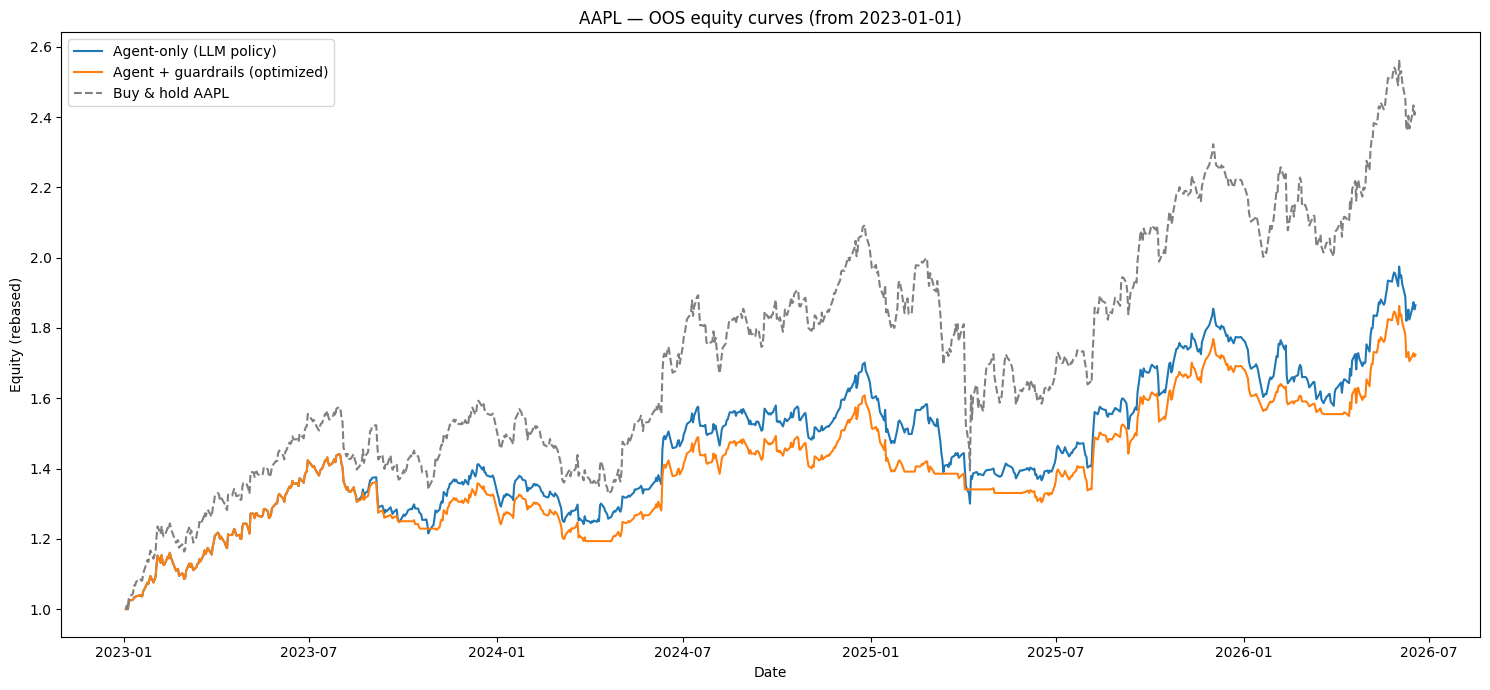

In [14]:
plt.figure(figsize=(15, 7))
plt.plot(eq_agent_oos.index, eq_agent_oos.values, label="Agent-only (LLM policy)")
plt.plot(eq_guard_oos.index, eq_guard_oos.values, label="Agent + guardrails (optimized)")
plt.plot(eq_bh_oos.index, eq_bh_oos.values, label="Buy & hold AAPL", linestyle="--", color="gray")
plt.title(f"{SYMBOL}: OOS equity curves (from {OOS_START})")
plt.xlabel("Date")
plt.ylabel("Equity (rebased)")
plt.legend()
plt.tight_layout()
plt.show()

## 13.5) Performance metrics table

Computes six standard backtest metrics for all three OOS equity curves and displays them side by side.

| Metric | What it measures |
|---|---|
| **CAGR** | Compound annual growth rate: raw return per year |
| **Annual Volatility** | Annualised daily return std: how much the curve bounces |
| **Sharpe Ratio** | Annualised mean return / annualised volatility: return per unit of total risk |
| **Sortino Ratio** | Annualised mean return / downside volatility: penalises only losses, not upside swings |
| **Max Drawdown** | Largest peak-to-trough decline: worst-case loss from any entry point |
| **Calmar Ratio** | CAGR / \|Max Drawdown\|: return per unit of tail risk |

**What to look for:** the guardrail should show a meaningfully lower Max Drawdown and higher Calmar than agent-only, confirming it provides genuine downside protection. A modest CAGR reduction in exchange for significantly better Calmar is a favourable trade-off for risk-conscious investors.

In [15]:
import pandas as pd
import numpy as np

def max_drawdown(equity: pd.Series) -> float:
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min())

def cagr(equity: pd.Series) -> float:
    # Assume ~252 trading days/year
    n = len(equity)
    years = n / 252.0
    if years <= 0:
        return float("nan")
    return float(equity.iloc[-1] ** (1.0 / years) - 1.0)

def annual_volatility(equity: pd.Series) -> float:
    r = equity.pct_change().fillna(0.0)
    return float(r.std(ddof=0) * math.sqrt(252))

def sharpe_ratio(equity: pd.Series) -> float:
    r = equity.pct_change().fillna(0.0)
    ann_ret = float(r.mean() * 252)
    ann_vol = float(r.std(ddof=0) * math.sqrt(252))
    return float(ann_ret / (ann_vol + 1e-12))

def sortino_ratio(equity: pd.Series) -> float:
    r = equity.pct_change().fillna(0.0)
    ann_ret = float(r.mean() * 252)
    downside = r.copy()
    downside[downside > 0] = 0.0
    down_dev = float(downside.std(ddof=0) * math.sqrt(252))
    return float(ann_ret / (down_dev + 1e-12))

def calmar_ratio(equity: pd.Series) -> float:
    mdd = abs(max_drawdown(equity))
    return float(cagr(equity) / (mdd + 1e-12))

def _metrics(equity: pd.Series) -> dict:
    return {
        "Sharpe Ratio": sharpe_ratio(equity),
        "CAGR": cagr(equity),
        "Annual Volatility": annual_volatility(equity),
        "Sortino Ratio": sortino_ratio(equity),
        "Calmar Ratio": calmar_ratio(equity),
        "Max Drawdown": max_drawdown(equity),
    }

def metrics_table(curves: dict) -> pd.DataFrame:
    # curves: {label -> equity Series}
    return pd.DataFrame({label: _metrics(eq) for label, eq in curves.items()}).T

# B1: include buy-and-hold AAPL as the benchmark column.
mt = metrics_table({
    "Agent-only": eq_agent_oos,
    "Agent + Guardrails": eq_guard_oos,
    "Buy & Hold AAPL": eq_bh_oos,
})

# Pretty formatting for display (percent columns)
pretty = mt.copy()
for col in ["CAGR", "Annual Volatility", "Max Drawdown"]:
    pretty[col] = (pretty[col] * 100).map(lambda x: f"{x:,.2f}%")
for col in ["Sharpe Ratio", "Sortino Ratio", "Calmar Ratio"]:
    pretty[col] = pretty[col].map(lambda x: f"{float(x):,.3f}")

pretty

,Sharpe Ratio,CAGR,Annual Volatility,Sortino Ratio,Calmar Ratio,Max Drawdown
Agent-only,1.066,19.83%,18.60%,1.837,0.841,-23.58%
Agent + Guardrails,1.040,17.13%,16.52%,1.787,0.905,-18.94%
Buy & Hold AAPL,1.139,29.30%,25.39%,1.968,0.878,-33.36%


## 14) Save artefacts

Exports four CSV files for use in the blog post or offline analysis:

| File | Contents |
|---|---|
| `equity_aapl_agent_only_oos.csv` | Daily agent-only equity curve (rebased to 1.0) |
| `equity_aapl_agent_guardrailed_oos.csv` | Daily guardrailed equity curve (rebased to 1.0) |
| `equity_aapl_buy_and_hold_oos.csv` | Daily buy-and-hold benchmark (rebased to 1.0) |
| `metrics_aapl_oos.csv` | Six-metric summary table for all three strategies |

In [16]:
eq_agent_oos.to_csv("equity_aapl_agent_only_oos.csv")
eq_guard_oos.to_csv("equity_aapl_agent_guardrailed_oos.csv")
eq_bh_oos.to_csv("equity_aapl_buy_and_hold_oos.csv")
mt.to_csv("metrics_aapl_oos.csv")
print("Saved: equity_aapl_agent_only_oos.csv")
print("Saved: equity_aapl_agent_guardrailed_oos.csv")
print("Saved: equity_aapl_buy_and_hold_oos.csv")
print("Saved: metrics_aapl_oos.csv")

Saved: equity_aapl_agent_only_oos.csv
Saved: equity_aapl_agent_guardrailed_oos.csv
Saved: equity_aapl_buy_and_hold_oos.csv
Saved: metrics_aapl_oos.csv
